In [1]:
%matplotlib inline
from pathlib import Path
import json, random
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Add, AveragePooling2D, BatchNormalization, Concatenate, Conv2D, Dense, Dropout, GlobalAveragePooling1D, GlobalAveragePooling2D, Input, LayerNormalization, MultiHeadAttention, Reshape
from tensorflow.keras.optimizers import Adam
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
GENRES=["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]
PROJECT_ROOT=Path.cwd().resolve()
if PROJECT_ROOT.name=='notebooks': PROJECT_ROOT=PROJECT_ROOT.parent
FEATURES_PATH=PROJECT_ROOT/'dataset'/'features_3.0_sec.json'; MODELS_DIR=PROJECT_ROOT/'models'; MODELS_DIR.mkdir(parents=True,exist_ok=True)
print(PROJECT_ROOT); print(FEATURES_PATH)

C:\Users\Muham\Desktop\Data (1)\music-genre-classification
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\dataset\features_3.0_sec.json


In [2]:
with FEATURES_PATH.open('r',encoding='utf-8') as fp: data=json.load(fp)
X_raw=np.array(data['mfcc'],dtype=np.float32); y=np.array(data['genre_num'],dtype=np.int64)
idx=np.arange(len(y))
train_idx,test_idx,y_train,y_test=train_test_split(idx,y,test_size=0.30,random_state=SEED,stratify=y)
train_idx,val_idx,y_train,y_val=train_test_split(train_idx,y_train,test_size=0.20,random_state=SEED,stratify=y_train)
def engineer(X):
    delta=librosa.feature.delta(X,axis=1)
    delta2=librosa.feature.delta(X,order=2,axis=1)
    return np.stack([X,delta,delta2],axis=-1).astype(np.float32)
X_train=engineer(X_raw[train_idx]); X_val=engineer(X_raw[val_idx]); X_test=engineer(X_raw[test_idx])
mean=X_train.mean(axis=(0,1),keepdims=True); std=X_train.std(axis=(0,1),keepdims=True)+1e-8
X_train=(X_train-mean)/std; X_val=(X_val-mean)/std; X_test=(X_test-mean)/std
np.savez(MODELS_DIR/'densenet_vit_feature_engineering_normalization.npz',mean=mean,std=std)
input_shape=X_train.shape[1:]
print('Raw MFCC:',X_raw.shape); print('Engineered input:',X_train.shape); print('Channels: MFCC, delta, delta-delta'); print('Input shape:',input_shape)

Raw MFCC: (9990, 132, 13)
Engineered input: (5594, 132, 13, 3)
Channels: MFCC, delta, delta-delta
Input shape: (132, 13, 3)


In [3]:
def plot_history(history,title):
    fig,axes=plt.subplots(1,2,figsize=(14,4))
    axes[0].plot(history.history['accuracy'],label='training accuracy'); axes[0].plot(history.history['val_accuracy'],label='validation accuracy'); axes[0].set_title(title+' - Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=.25)
    axes[1].plot(history.history['loss'],label='training loss'); axes[1].plot(history.history['val_loss'],label='validation loss'); axes[1].set_title(title+' - Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=.25)
    plt.tight_layout(); plt.show()
def show_cm(model,Xc,yc,title):
    yp=np.argmax(model.predict(Xc,verbose=0),axis=1); cm=confusion_matrix(yc,yp); fig,ax=plt.subplots(figsize=(9,9)); ConfusionMatrixDisplay(cm,display_labels=GENRES).plot(ax=ax,cmap='Blues',xticks_rotation=45,colorbar=False); plt.title(title); plt.tight_layout(); plt.show(); print(classification_report(yc,yp,target_names=GENRES,zero_division=0)); return yp

In [4]:
def dense_layer(x,g):
    y=BatchNormalization()(x); y=tf.keras.layers.Activation('relu')(y); y=Conv2D(g,3,padding='same')(y); return Concatenate()([x,y])
def dense_block(x,n,g):
    for _ in range(n): x=dense_layer(x,g)
    return x
def transition(x,f):
    x=BatchNormalization()(x); x=tf.keras.layers.Activation('relu')(x); x=Conv2D(f,1,padding='same')(x); return AveragePooling2D(2,padding='same')(x)
def build_fe_densenet(shape):
    i=Input(shape=shape); x=Conv2D(32,3,padding='same',activation='relu')(i); x=dense_block(x,2,8); x=transition(x,32); x=dense_block(x,2,12); x=transition(x,40); x=dense_block(x,2,16); x=BatchNormalization()(x); x=tf.keras.layers.Activation('relu')(x); x=GlobalAveragePooling2D()(x); x=Dropout(.30)(x); x=Dense(64,activation='relu')(x); x=Dropout(.20)(x); o=Dense(len(GENRES),activation='softmax')(x); return Model(i,o,name='feature_engineered_densenet')
def transformer(x,e,h,m,d):
    a=LayerNormalization(epsilon=1e-6)(x); a=MultiHeadAttention(num_heads=h,key_dim=e//h,dropout=d)(a,a); x=Add()([x,a]); z=LayerNormalization(epsilon=1e-6)(x); z=Dense(m,activation='gelu')(z); z=Dropout(d)(z); z=Dense(e)(z); z=Dropout(d)(z); return Add()([x,z])
def build_fe_vit(shape):
    i=Input(shape=shape); x=Conv2D(48,kernel_size=(11,2),strides=(11,2),padding='valid')(i); tokens=x.shape[1]*x.shape[2]; x=Reshape((tokens,48))(x); pos=tf.range(0,tokens); x=x+tf.keras.layers.Embedding(input_dim=tokens,output_dim=48)(pos); x=transformer(x,48,4,96,.15); x=LayerNormalization(epsilon=1e-6)(x); x=GlobalAveragePooling1D()(x); x=Dropout(.25)(x); x=Dense(64,activation='relu')(x); x=Dropout(.20)(x); o=Dense(len(GENRES),activation='softmax')(x); return Model(i,o,name='feature_engineered_vit')

Feature engineered DenseNet


Model: "feature_engineered_densenet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 132, 13,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 132, 13,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 132, 13,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 132, 13,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 132, 13,   │      2,312 │ activation[0][0]  │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 132, 13,   │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 40)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 132, 13,   │        160 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 132, 13,   │          0 │ batch_normalizat… │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 132, 13,   │      2,888 │ activation_1[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 132, 13,   │          0 │ concatenate[0][0… │
│ (Concatenate)       │ 48)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 132, 13,   │        192 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 132, 13,   │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 132, 13,   │      1,568 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 66, 7, 32) │          0 │ conv2d_3[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 66, 7, 32) │        128 │ average_pooling2… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 66, 7, 32) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 66, 7, 12) │      3,468 │ activation_3[0][

 Total params: 39,034 (152.48 KB)

 Trainable params: 38,194 (149.20 KB)

...

Epoch 19/20


88/88 - 17s - 188ms/step - accuracy: 0.7381 - loss: 0.7535 - val_accuracy: 0.7305 - val_loss: 0.7332 - learning_rate: 5.0000e-04


Epoch 20/20


88/88 - 17s - 189ms/step - accuracy: 0.7563 - loss: 0.7018 - val_accuracy: 0.7748 - val_loss: 0.6427 - learning_rate: 2.5000e-04


Training accuracy: 0.8398
Validation accuracy: 0.7748
Test accuracy: 0.7618
Loss: 0.4955
Validation loss: 0.6427
Test loss: 0.6842


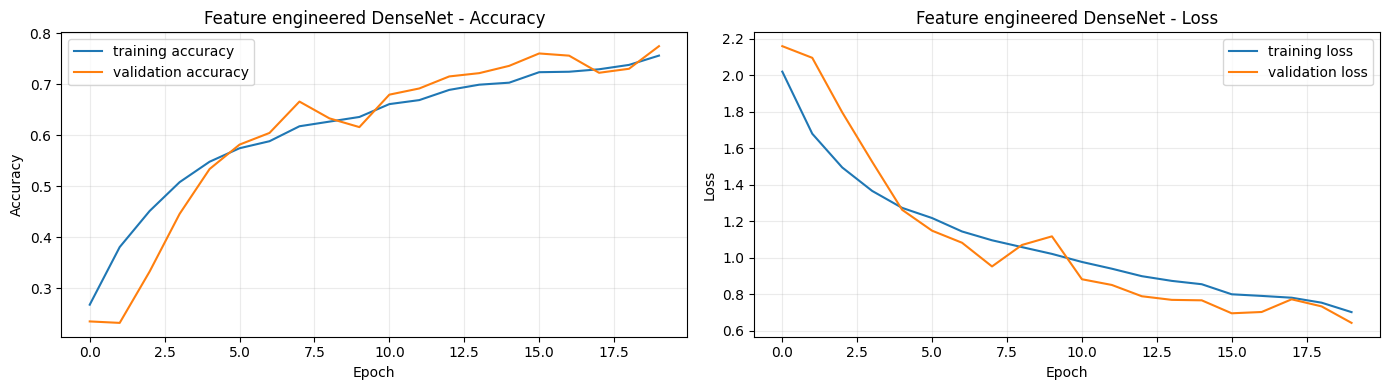

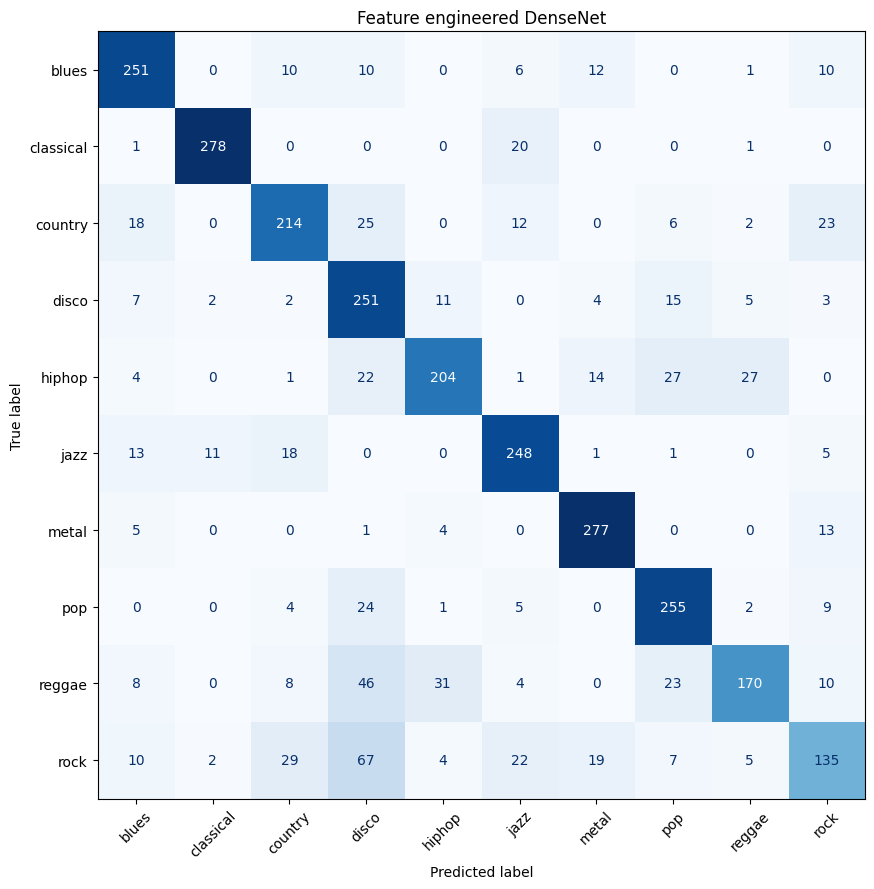

              precision    recall  f1-score   support

       blues       0.79      0.84      0.81       300
   classical       0.95      0.93      0.94       300
     country       0.75      0.71      0.73       300
       disco       0.56      0.84      0.67       300
      hiphop       0.80      0.68      0.74       300
        jazz       0.78      0.84      0.81       297
       metal       0.85      0.92      0.88       300
         pop       0.76      0.85      0.80       300
      reggae       0.80      0.57      0.66       300
        rock       0.65      0.45      0.53       300

    accuracy                           0.76      2997
   macro avg       0.77      0.76      0.76      2997
weighted avg       0.77      0.76      0.76      2997

Feature engineered Vision Transformer


Model: "feature_engineered_vit"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 132, 13,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 12, 6, 48) │      3,216 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 72, 48)    │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 72, 48)    │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 72, 48)    │         96 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 72, 48)    │      9,408 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 72, 48)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 48)    │         96 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 72, 96)    │      4,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 72, 96)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 72, 48)    │      4,656 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 72, 48)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 72, 48)    │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 48)    │         96 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 48)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      3,136 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │        650 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,058 (101.79 KB)

 Trainable params: 26,058 (101.79 KB)

...

Epoch 19/20


88/88 - 2s - 24ms/step - accuracy: 0.5701 - loss: 1.1703 - val_accuracy: 0.5804 - val_loss: 1.1699 - learning_rate: 5.0000e-04


Epoch 20/20


88/88 - 2s - 23ms/step - accuracy: 0.5749 - loss: 1.1639 - val_accuracy: 0.5826 - val_loss: 1.1899 - learning_rate: 5.0000e-04


Training accuracy: 0.6148
Validation accuracy: 0.5833
Test accuracy: 0.5542
Loss: 1.0626
Validation loss: 1.1851
Test loss: 1.2254


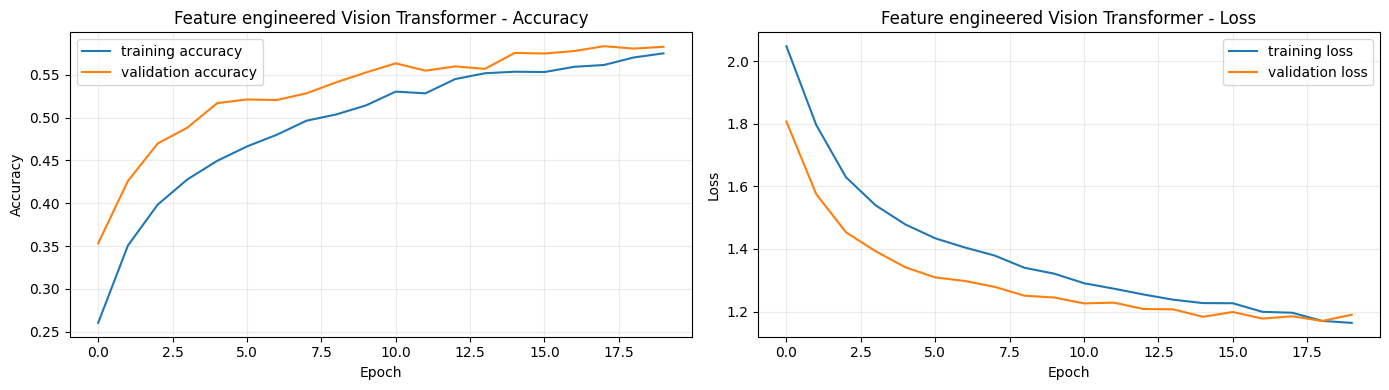

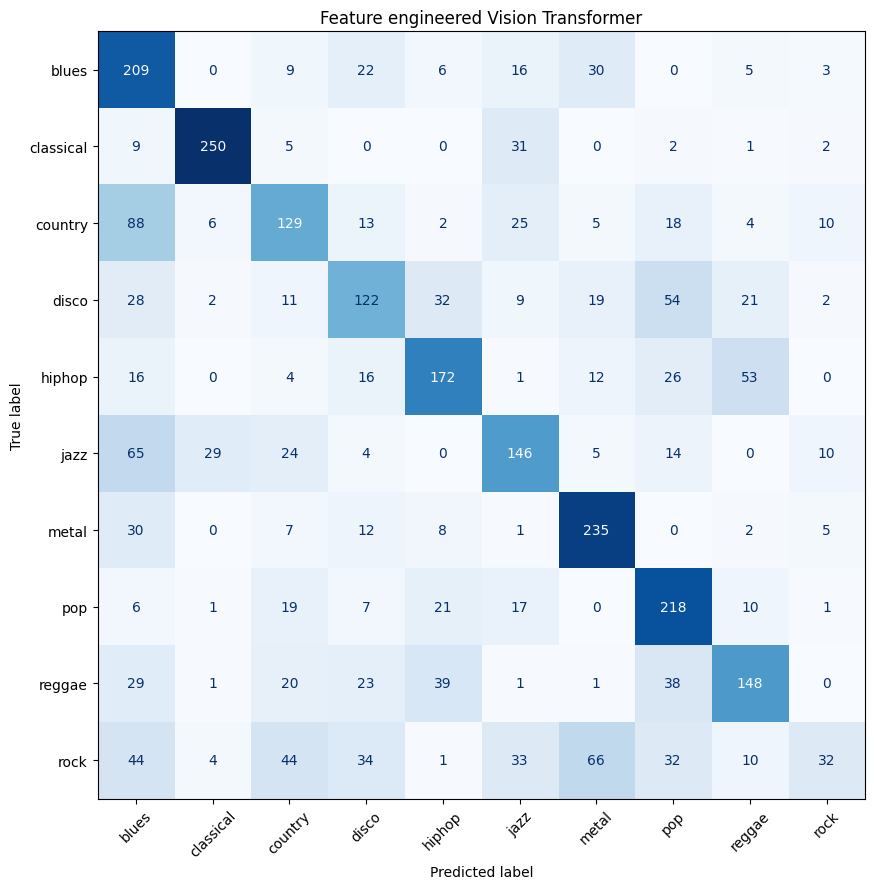

              precision    recall  f1-score   support

       blues       0.40      0.70      0.51       300
   classical       0.85      0.83      0.84       300
     country       0.47      0.43      0.45       300
       disco       0.48      0.41      0.44       300
      hiphop       0.61      0.57      0.59       300
        jazz       0.52      0.49      0.51       297
       metal       0.63      0.78      0.70       300
         pop       0.54      0.73      0.62       300
      reggae       0.58      0.49      0.53       300
        rock       0.49      0.11      0.18       300

    accuracy                           0.55      2997
   macro avg       0.56      0.55      0.54      2997
weighted avg       0.56      0.55      0.54      2997



In [5]:
TRIALS=[('Feature engineered DenseNet',build_fe_densenet),('Feature engineered Vision Transformer',build_fe_vit)]
results=[]; trained={}
for label,builder in TRIALS:
    print('='*80); print(label); print('='*80)
    model=builder(input_shape); model.compile(optimizer=Adam(learning_rate=.0005),loss='sparse_categorical_crossentropy',metrics=['accuracy']); model.summary()
    cb=[EarlyStopping(monitor='val_accuracy',patience=5,restore_best_weights=True),ReduceLROnPlateau(monitor='val_loss',factor=.5,patience=3,min_lr=1e-6),ModelCheckpoint(MODELS_DIR/f'{model.name}_checkpoint.keras',monitor='val_accuracy',save_best_only=True)]
    history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=20,batch_size=64,callbacks=cb,verbose=2)
    tl,ta=model.evaluate(X_train,y_train,verbose=0); vl,va=model.evaluate(X_val,y_val,verbose=0); tel,tea=model.evaluate(X_test,y_test,verbose=0); yp=np.argmax(model.predict(X_test,verbose=0),axis=1)
    results.append({'model':label,'training_accuracy':ta,'validation_accuracy':va,'test_accuracy':tea,'loss':tl,'validation_loss':vl,'test_loss':tel,'precision_macro':precision_score(y_test,yp,average='macro',zero_division=0),'precision_weighted':precision_score(y_test,yp,average='weighted',zero_division=0),'recall_macro':recall_score(y_test,yp,average='macro',zero_division=0),'recall_weighted':recall_score(y_test,yp,average='weighted',zero_division=0),'f1_macro':f1_score(y_test,yp,average='macro',zero_division=0),'f1_weighted':f1_score(y_test,yp,average='weighted',zero_division=0),'epochs_run':len(history.history['loss'])})
    trained[label]=model; model.save(MODELS_DIR/f'{model.name}.keras'); model.save(MODELS_DIR/f'{model.name}.h5')
    print(f'Training accuracy: {ta:.4f}'); print(f'Validation accuracy: {va:.4f}'); print(f'Test accuracy: {tea:.4f}'); print(f'Loss: {tl:.4f}'); print(f'Validation loss: {vl:.4f}'); print(f'Test loss: {tel:.4f}'); plot_history(history,label); show_cm(model,X_test,y_test,label)

In [6]:
baselines=[{'model':'Compact DenseNet baseline','validation_accuracy':.7598,'test_accuracy':.7421},{'model':'Compact Vision Transformer baseline','validation_accuracy':.5368,'test_accuracy':.5138}]
comparison_df=pd.DataFrame(results).sort_values('validation_accuracy',ascending=False).reset_index(drop=True); display(comparison_df); display(pd.DataFrame(baselines))
comparison_df.to_csv(MODELS_DIR/'feature_engineered_densenet_vit_comparison.csv',index=False,encoding='utf-8-sig')
best_name=comparison_df.iloc[0]['model']; best=trained[best_name]; best.save(MODELS_DIR/'best_feature_engineered_vision_model.keras'); best.save(MODELS_DIR/'best_feature_engineered_vision_model.h5')
print('Best feature engineered model:',best_name); print('Validation accuracy:',comparison_df.iloc[0]['validation_accuracy']); print(MODELS_DIR/'best_feature_engineered_vision_model.h5')

,model,training_accuracy,validation_accuracy,test_accuracy,loss,validation_loss,test_loss,precision_macro,precision_weighted,recall_macro,recall_weighted,f1_macro,f1_weighted,epochs_run
0,Feature engineered DenseNet,0.839828,0.774839,0.761762,0.495461,0.642696,0.684195,0.768924,0.768913,0.761835,0.761762,0.757841,0.757792,20
1,Feature engineered Vision Transformer,0.614766,0.583274,0.554221,1.062617,1.185134,1.225440,0.558940,0.558978,0.554158,0.554221,0.536997,0.537028,20


,model,validation_accuracy,test_accuracy
0,Compact DenseNet baseline,0.7598,0.7421
1,Compact Vision Transformer baseline,0.5368,0.5138


Best feature engineered model: Feature engineered DenseNet
Validation accuracy: 0.7748391628265381
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\models\best_feature_engineered_vision_model.h5
